In [1]:
import numpy as np
import pandas as pd

from src.data_loader import download_prices

from src.returns import (
    calculate_simple_returns,
    calculate_log_returns,
    validate_returns
)

from src.portfolio import (
    calculate_portfolio_returns,
    calculate_portfolio_pnl
)

from src.risk_metrics import (
    calculate_portfolio_statistics
)

from src.historical_simulation_var import (
    historical_var
)

from src.historical_simulation_es import (
    historical_expected_shortfall
)

from src.variance_covariance_var import (
    calculate_portfolio_mean_return,
    calculate_portfolio_volatility,
    calculate_variance_covariance_var
)

from src.variance_covariance_es import (
    calculate_variance_covariance_es
)

In [2]:
tickers = [
    "RELIANCE.NS",
    "ESCORTS.NS",
    "INFY.NS",
    "ABB.NS",
    "HDFCBANK.NS"
]

#weightage of stocks in portfolio
weights = [
    0.20,   # RELIANCE
    0.20,   # ESCORTS
    0.20,   # INFY
    0.20,   # ABB
    0.20    # HDFCBANK
]

#assigning portfolio value in Rs
portfolio_value = 10_000_000

In [3]:
prices = download_prices(
    tickers,
    "2022-04-01",
    "2026-03-31"
)

prices = prices.round(2)

print(prices.head())

[*********************100%***********************]  5 of 5 completed

Ticker       ABB.NS  ESCORTS.NS  HDFCBANK.NS  INFY.NS  RELIANCE.NS
Date                                                              
2022-04-01  2043.44     1635.69       704.66  1672.63      1202.88
2022-04-04  2059.15     1700.33       775.21  1654.53      1206.44
2022-04-05  2133.57     1795.94       752.50  1635.33      1189.39
2022-04-06  2135.41     1820.12       725.64  1606.99      1186.21
2022-04-07  2118.69     1652.36       709.69  1591.31      1165.29


In [4]:
returns = calculate_simple_returns(prices)

print(returns.head())

Ticker        ABB.NS  ESCORTS.NS  HDFCBANK.NS   INFY.NS  RELIANCE.NS
Date                                                                
2022-04-04  0.007688    0.039518     0.100119 -0.010821     0.002960
2022-04-05  0.036141    0.056230    -0.029295 -0.011605    -0.014132
2022-04-06  0.000862    0.013464    -0.035694 -0.017330    -0.002674
2022-04-07 -0.007830   -0.092170    -0.021981 -0.009757    -0.017636
2022-04-08  0.021348   -0.061246    -0.001395  0.001986     0.016631


In [5]:
print(validate_returns(returns))

{'rows': 986, 'columns': 5, 'missing_values': np.int64(0), 'infinite_values': np.int64(0)}


In [6]:
portfolio_returns = calculate_portfolio_returns(
    returns,
    weights
)

print(prices.head().round(2))

Ticker       ABB.NS  ESCORTS.NS  HDFCBANK.NS  INFY.NS  RELIANCE.NS
Date                                                              
2022-04-01  2043.44     1635.69       704.66  1672.63      1202.88
2022-04-04  2059.15     1700.33       775.21  1654.53      1206.44
2022-04-05  2133.57     1795.94       752.50  1635.33      1189.39
2022-04-06  2135.41     1820.12       725.64  1606.99      1186.21
2022-04-07  2118.69     1652.36       709.69  1591.31      1165.29


In [7]:
#calculating daily PnL
portfolio_pnl = calculate_portfolio_pnl(
    portfolio_returns,
    portfolio_value
)

print(portfolio_pnl.head(10))

Date
2022-04-04    278927.991277
2022-04-05     74678.213350
2022-04-06    -82743.442739
2022-04-07   -298747.188883
2022-04-08    -45351.545925
2022-04-11   -110984.815443
2022-04-12   -156029.769147
2022-04-13    -16178.120083
2022-04-18   -279785.225393
2022-04-19   -104897.900524
Name: Portfolio P&L, dtype: float64


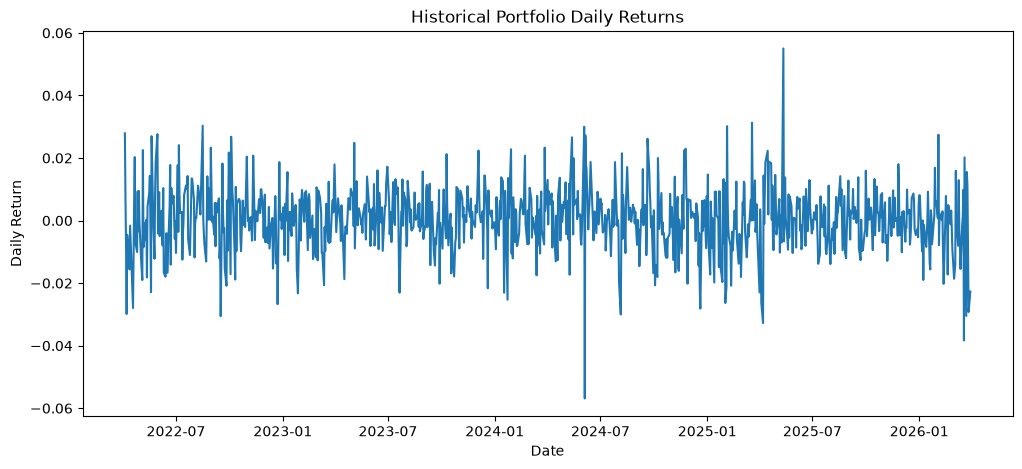

In [8]:
#Plotting Portfolio returns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    portfolio_returns.index,
    portfolio_returns
)

plt.title("Historical Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

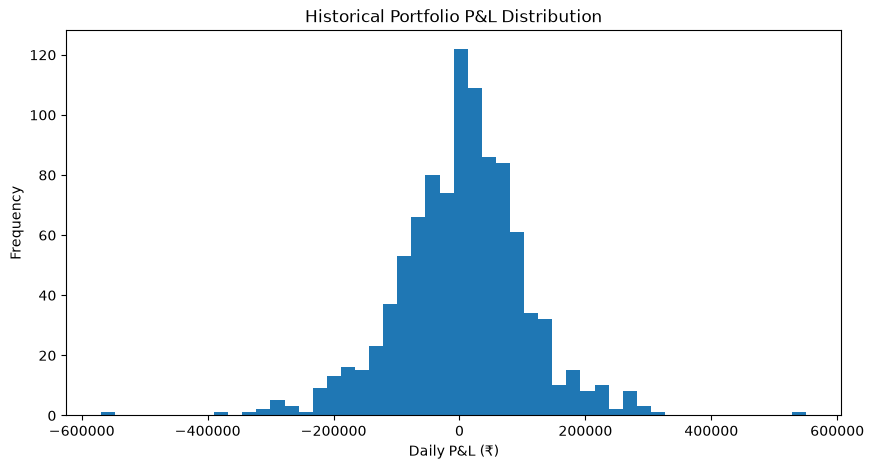

In [9]:
#Plotting PnL Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_pnl,
    bins=50
)

plt.title("Historical Portfolio P&L Distribution")
plt.xlabel("Daily P&L (₹)")
plt.ylabel("Frequency")

plt.show()

In [10]:
#portfolio statistics

statistics = calculate_portfolio_statistics(
    portfolio_returns
)

for key, value in statistics.items():
    print(f"{key}: {value:.6f}")

mean_return: 0.000418
volatility: 0.010154
minimum_return: -0.056875
maximum_return: 0.055030
skewness: -0.160656
kurtosis: 2.364912


In [11]:
#Calculate Historical VaR
# 1-day 95% VaR 
var_95 = historical_var(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.95
)

# 1-day 99% VaR 
var_99 = historical_var(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.99
)

print(f"95% 1-Day VaR: ₹{var_95:,.2f}")
print(f"99% 1-Day VaR: ₹{var_99:,.2f}")

95% 1-Day VaR: ₹167,645.10
99% 1-Day VaR: ₹269,176.24


In [12]:
# Expected Shortfall at 95% CI
es_95 = historical_expected_shortfall(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.95
)

# Expected Shortfall at 99% CI
es_99 = historical_expected_shortfall(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.99
)

print(f"95% Expected Shortfall: ₹{es_95:,.2f}")
print(f"99% Expected Shortfall: ₹{es_99:,.2f}")

95% Expected Shortfall: ₹229,691.30
99% Expected Shortfall: ₹334,273.11


In [13]:
#Market Risk Summary
print("=" * 50)
print("           MARKET RISK SUMMARY")
print("=" * 50)

print(f"\nPortfolio Value: ₹{portfolio_value:,.2f} Rs")

print("\n--- Portfolio Statistics ---")

print(
    f"Mean Daily Return: "
    f"{statistics['mean_return'] * 100:.4f}%"
)

print(
    f"Daily Volatility: "
    f"{statistics['volatility'] * 100:.4f}%"
)

print(
    f"Worst Daily Return: "
    f"{statistics['minimum_return'] * 100:.4f}%"
)

print(
    f"Best Daily Return: "
    f"{statistics['maximum_return'] * 100:.4f}%"
)

print("\n--- Value at Risk ---")

print(
    f"95% Historical VaR: "
    f"₹{var_95:,.2f}"
)

print(
    f"99% Historical VaR: "
    f"₹{var_99:,.2f}"
)

print("\n--- Expected Shortfall ---")

print(
    f"95% Expected Shortfall: "
    f"₹{es_95:,.2f}"
)

print(
    f"99% Expected Shortfall: "
    f"₹{es_99:,.2f}"
)

print("\n" + "=" * 50)

           MARKET RISK SUMMARY

Portfolio Value: ₹10,000,000.00 Rs

--- Portfolio Statistics ---
Mean Daily Return: 0.0418%
Daily Volatility: 1.0154%
Worst Daily Return: -5.6875%
Best Daily Return: 5.5030%

--- Value at Risk ---
95% Historical VaR: ₹167,645.10
99% Historical VaR: ₹269,176.24

--- Expected Shortfall ---
95% Expected Shortfall: ₹229,691.30
99% Expected Shortfall: ₹334,273.11



In [14]:
# Variance-Covariance VaR

# portfolio mean return
portfolio_mean_vc = calculate_portfolio_mean_return(
    returns,
    np.array(weights)
)

print(
    f"Portfolio Mean Daily Return: "
    f"{portfolio_mean_vc * 100:.4f}%"
)

# calculate portfolio volatility
portfolio_volatility_vc = calculate_portfolio_volatility(
    returns,
    np.array(weights)
)

print(
    f"Portfolio Daily Volatility: "
    f"{portfolio_volatility_vc * 100:.4f}%"
)

# calculate 95% VaR
var_vc_95 = calculate_variance_covariance_var(
    returns,
    np.array(weights),
    portfolio_value,
    confidence_level=0.95
)

print(
    f"Variance-Covariance 95% VaR: "
    f"₹{var_vc_95:,.2f}"
)

# calculate 99% VaR
var_vc_99 = calculate_variance_covariance_var(
    returns,
    np.array(weights),
    portfolio_value,
    confidence_level=0.99
)

print(
    f"Variance-Covariance 99% VaR: "
    f"₹{var_vc_99:,.2f}"
)

Portfolio Mean Daily Return: 0.0418%
Portfolio Daily Volatility: 1.0154%
Variance-Covariance 95% VaR: ₹162,844.75
Variance-Covariance 99% VaR: ₹232,045.02


In [15]:
#calculate 95% ES
es_vc_95 = calculate_variance_covariance_es(
    returns,
    np.array(weights),
    portfolio_value,
    confidence_level=0.95
)

print(
    f"Variance-Covariance 95% ES: "
    f"₹{es_vc_95:,.2f}"
)

#calculate 99% ES
es_vc_99 = calculate_variance_covariance_es(
    returns,
    np.array(weights),
    portfolio_value,
    confidence_level=0.99
)

print(
    f"Variance-Covariance 99% ES: "
    f"₹{es_vc_99:,.2f}"
)

Variance-Covariance 95% ES: ₹205,275.00
Variance-Covariance 99% ES: ₹266,454.18


In [16]:
risk_model_comparison = pd.DataFrame({
    "Model": [
        "Historical Simulation",
        "Variance-Covariance"
    ],
    "95% VaR": [
        var_95,
        var_vc_95
    ],
    "99% VaR": [
        var_99,
        var_vc_99
    ],
    "95% ES": [
        es_95,
        es_vc_95
    ],
    "99% ES": [
        es_99,
        es_vc_99
    ]
})

print(risk_model_comparison)

                   Model        95% VaR        99% VaR         95% ES  \
0  Historical Simulation  167645.096539  269176.235470  229691.300920   
1    Variance-Covariance  162844.749402  232045.023933  205274.997542   

          99% ES  
0  334273.108595  
1  266454.183355  
